# Projeto C318 - Previsão de Salários no Mercado de IA

**Objetivo**: Desenvolver um modelo preditivo para estimar o salário anual de vagas na área de IA/dados.

**Tipo de Problema**: Regressão

**Variável Alvo**: `salary`

---

## Sumário
1. Configuração e Reprodutibilidade
2. Carregamento dos Dados
3. Análise Exploratória (EDA)
4. Pré-processamento
5. Modelagem Supervisionada
6. Otimização de Hiperparâmetros
7. Modelagem Não Supervisionada
8. Conclusões

---
## 1. Configuração e Reprodutibilidade

In [2]:
# ============================================================
# SEED GLOBAL - Garantir reprodutibilidade
# ============================================================
SEED = 67

import random
import numpy as np

random.seed(SEED)
np.random.seed(SEED)

# ============================================================
# Imports
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
import pandas as pd

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
# Curva ROC One-vs-Rest (OvR)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin


from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, 
    balanced_accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    classification_report, 
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

# XGBoost
from xgboost import XGBRegressor

# Statsmodels para VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Otimização Bayesiana
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import time

# Configurações
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

print("Configuração concluída!")
print(f"Seed global: {SEED}")

Configuração concluída!
Seed global: 67


---
## 2. Carregamento dos Dados

In [3]:
# Carregar dataset
df = pd.read_csv('../data/AI Job Market Dataset.csv')

print(f"Shape: {df.shape}")
print(f"Linhas: {df.shape[0]:,}")
print(f"Colunas: {df.shape[1]}")

Shape: (10345, 19)
Linhas: 10,345
Colunas: 19


In [4]:
# Visualizar primeiras linhas
df.head(10)

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2
5,6,Machine Learning Engineer,Medium,Technology,Australia,Onsite,Senior,6,Master,1,0,1,1,0,165878,5,2021,High,2
6,7,Data Scientist,MNC,Technology,Germany,Remote,Entry,14,Bachelor,0,0,0,0,0,67027,8,2026,High,8
7,8,Data Analyst,Enterprise,Finance,UK,Onsite,Entry,4,PhD,1,0,1,0,1,78392,8,2023,High,7
8,9,Machine Learning Engineer,Startup,Education,Canada,Onsite,Mid,2,PhD,0,0,0,0,1,123840,5,2021,Low,3
9,10,Data Engineer,Enterprise,Retail,USA,Onsite,Senior,9,Master,1,0,0,0,1,112408,4,2024,High,7


In [5]:
# Informações do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   job_id                10345 non-null  int64 
 1   job_title             10345 non-null  object
 2   company_size          10345 non-null  object
 3   company_industry      10345 non-null  object
 4   country               10345 non-null  object
 5   remote_type           10345 non-null  object
 6   experience_level      10345 non-null  object
 7   years_experience      10345 non-null  int64 
 8   education_level       10345 non-null  object
 9   skills_python         10345 non-null  int64 
 10  skills_sql            10345 non-null  int64 
 11  skills_ml             10345 non-null  int64 
 12  skills_deep_learning  10345 non-null  int64 
 13  skills_cloud          10345 non-null  int64 
 14  salary                10345 non-null  int64 
 15  job_posting_month     10345 non-null

In [6]:
# Estatísticas descritivas
df.describe()

,job_id,years_experience,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,job_openings
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.00000,10345.000000,10345.000000,10345.00000
mean,5173.000000,6.950507,0.493088,0.503045,0.507878,0.498018,0.511455,113438.22726,6.502465,2023.000387,5.00406
std,2986.488601,4.320054,0.499976,0.500015,0.499962,0.500020,0.499893,31389.20106,3.473441,1.996856,2.58382
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45083.00000,1.000000,2020.000000,1.00000
25%,2587.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,89715.00000,4.000000,2021.000000,3.00000
50%,5173.000000,7.000000,0.000000,1.000000,1.000000,0.000000,1.000000,113082.00000,6.000000,2023.000000,5.00000
75%,7759.000000,11.000000,1.000000,1.000000,1.000000,1.000000,1.000000,134894.00000,10.000000,2025.000000,7.00000
max,10345.000000,14.000000,1.000000,1.000000,1.000000,1.000000,1.000000,204143.00000,12.000000,2026.000000,9.00000


---
## 3. Análise Exploratória de Dados (EDA)

### 3.1 Verificação de Valores Faltantes

In [7]:
# Valores faltantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Faltantes': missing,
    'Percentual (%)': missing_pct
})

print("Valores Faltantes por Coluna:")
print(missing_df[missing_df['Faltantes'] > 0] if missing.sum() > 0 else "Nenhum valor faltante!")

Valores Faltantes por Coluna:
Nenhum valor faltante!


### 3.2 Análise da Variável Alvo (salary)

In [8]:
# Estatísticas do salary
print("Estatísticas do Salário:")
print(f"  Mínimo:  ${df['salary'].min():,.0f}")
print(f"  Máximo:  ${df['salary'].max():,.0f}")
print(f"  Média:   ${df['salary'].mean():,.0f}")
print(f"  Mediana: ${df['salary'].median():,.0f}")
print(f"  Desvio:  ${df['salary'].std():,.0f}")

Estatísticas do Salário:
  Mínimo:  $45,083
  Máximo:  $204,143
  Média:   $113,438
  Mediana: $113,082
  Desvio:  $31,389


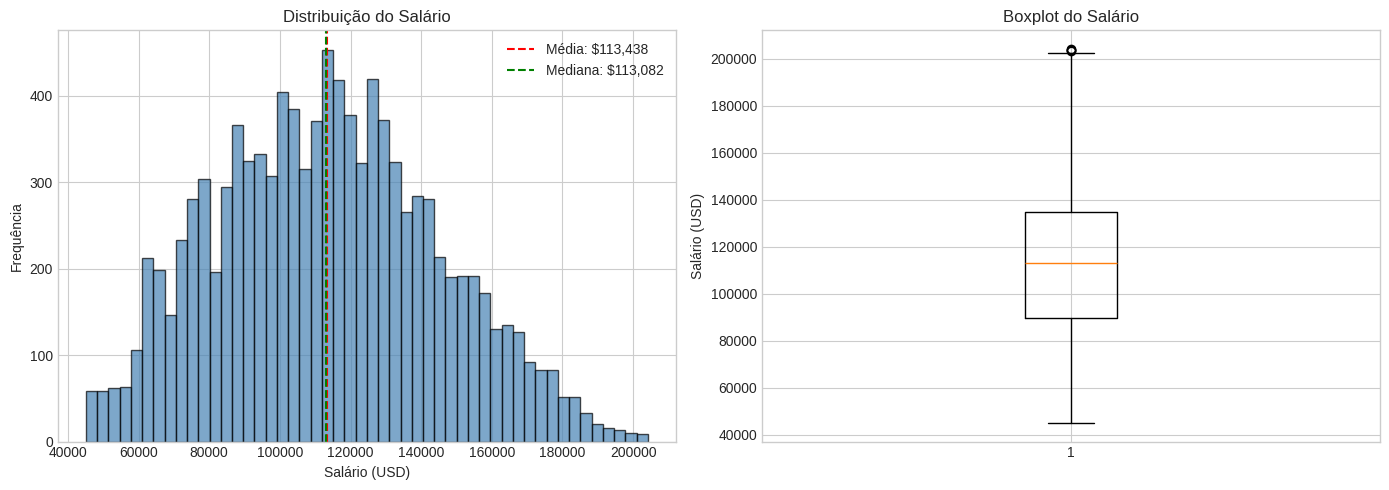

In [9]:
# Distribuição do salary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['salary'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Salário (USD)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição do Salário')
axes[0].axvline(df['salary'].mean(), color='red', linestyle='--', label=f"Média: ${df['salary'].mean():,.0f}")
axes[0].axvline(df['salary'].median(), color='green', linestyle='--', label=f"Mediana: ${df['salary'].median():,.0f}")
axes[0].legend()

# Boxplot
axes[1].boxplot(df['salary'], vert=True)
axes[1].set_ylabel('Salário (USD)')
axes[1].set_title('Boxplot do Salário')

plt.tight_layout()
plt.savefig('../reports/salary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Análise das Variáveis Categóricas

In [10]:
# Variáveis categóricas
cat_cols = ['job_title', 'company_size', 'company_industry', 'country', 
            'remote_type', 'experience_level', 'education_level', 'hiring_urgency']

print("Valores únicos por variável categórica:")
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())

Valores únicos por variável categórica:

job_title:
job_title
Business Analyst             1773
AI Engineer                  1742
Machine Learning Engineer    1740
Data Analyst                 1711
Data Scientist               1703
Data Engineer                1676
Name: count, dtype: int64

company_size:
company_size
Startup       2656
MNC           2593
Medium        2548
Enterprise    2548
Name: count, dtype: int64

company_industry:
company_industry
Technology    1787
E-commerce    1744
Finance       1724
Healthcare    1715
Education     1704
Retail        1671
Name: count, dtype: int64

country:
country
Germany      1498
Singapore    1490
Canada       1488
UK           1485
India        1470
USA          1459
Australia    1455
Name: count, dtype: int64

remote_type:
remote_type
Remote    3513
Hybrid    3420
Onsite    3412
Name: count, dtype: int64

experience_level:
experience_level
Entry     3513
Senior    3420
Mid       3412
Name: count, dtype: int64

education_level:
education_

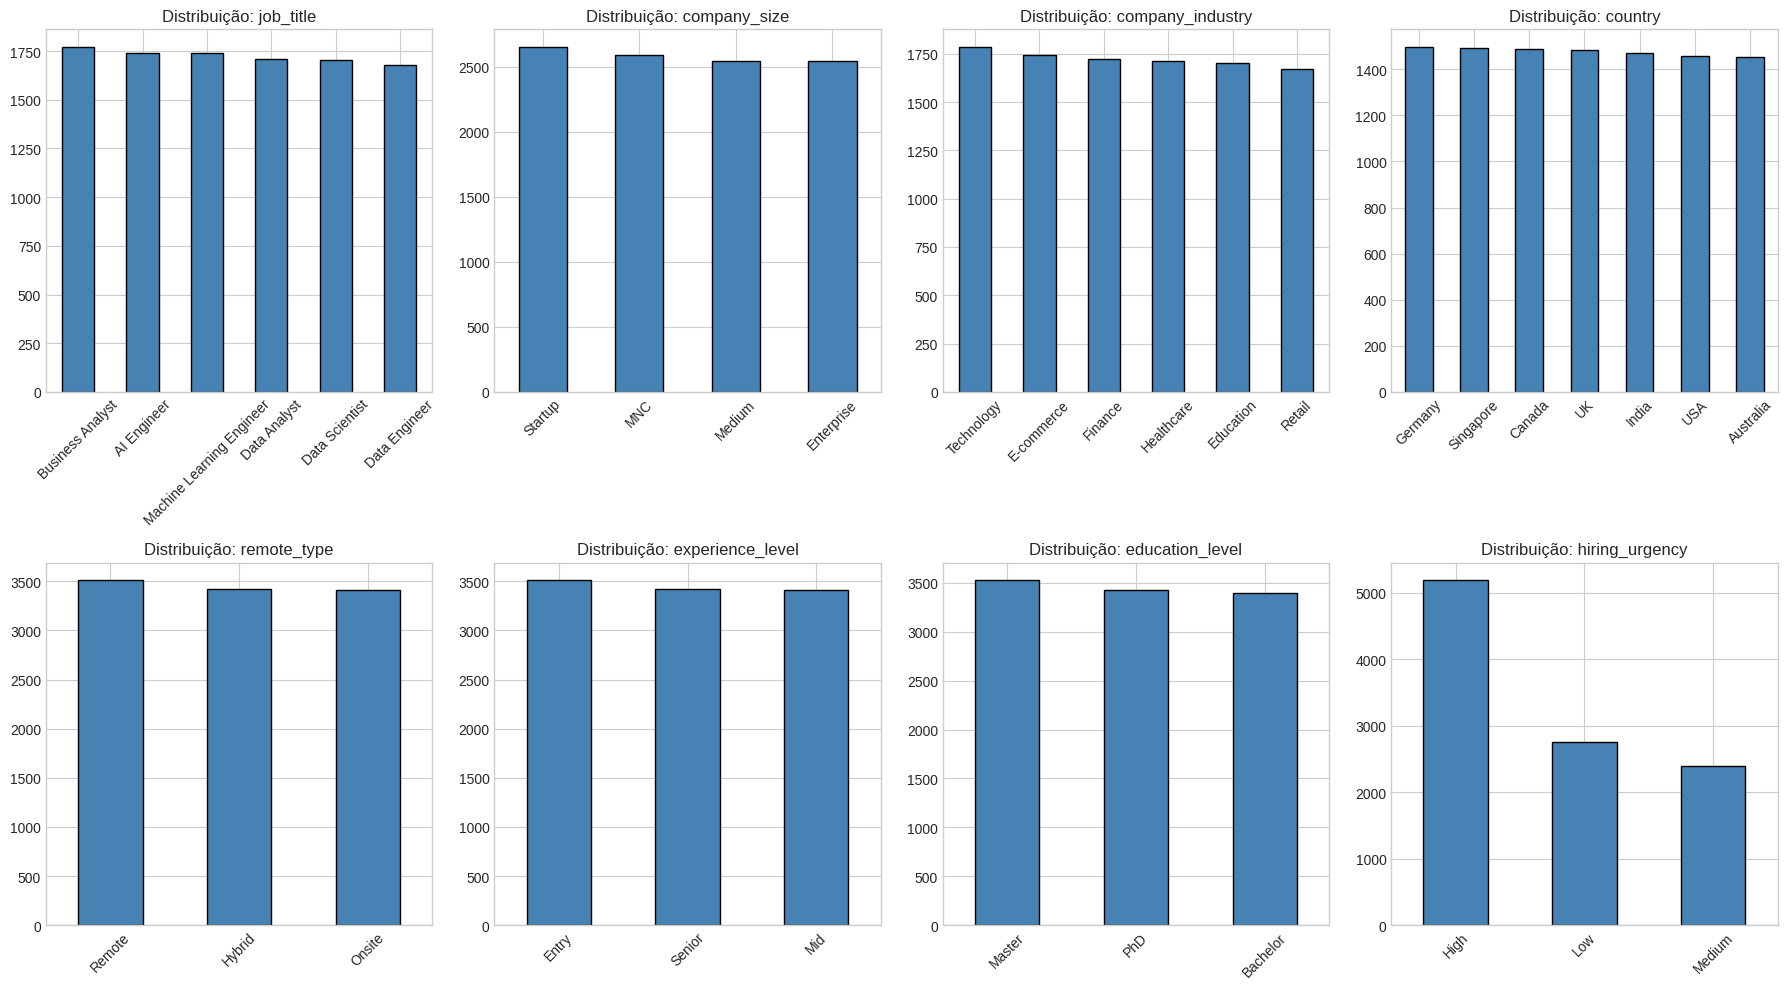

In [11]:
# Gráficos de barras para variáveis categóricas
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribuição: {col}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Salário por Categoria

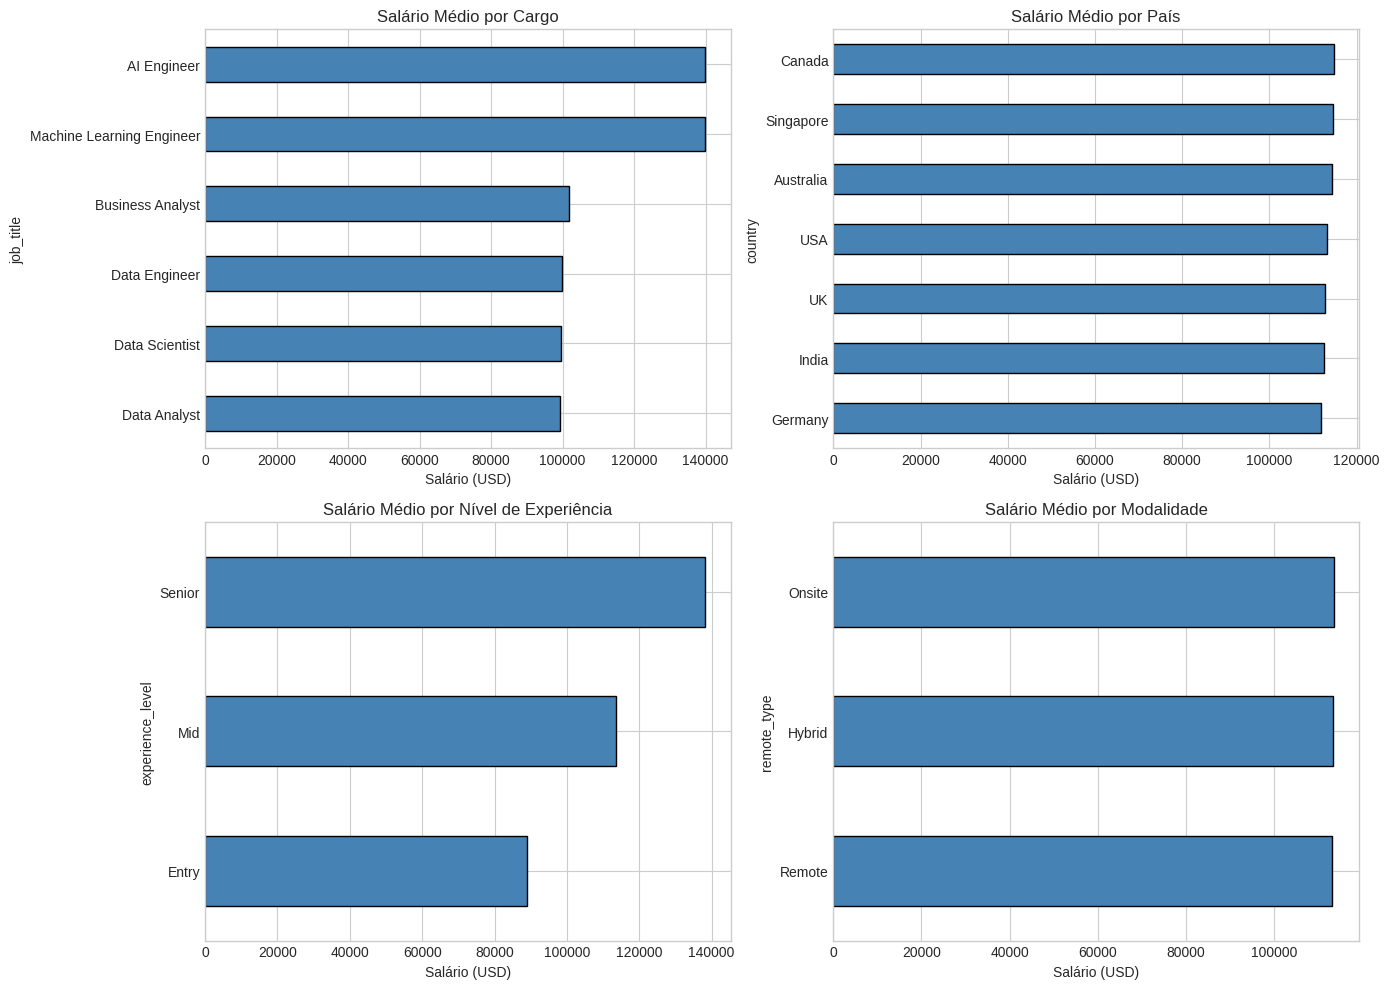

In [12]:
    # Salário médio por job_title
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Por cargo
    df.groupby('job_title')['salary'].mean().sort_values(ascending=True).plot(
        kind='barh', ax=axes[0, 0], color='steelblue', edgecolor='black')
    axes[0, 0].set_title('Salário Médio por Cargo')
    axes[0, 0].set_xlabel('Salário (USD)')

    # Por país
    df.groupby('country')['salary'].mean().sort_values(ascending=True).plot(
        kind='barh', ax=axes[0, 1], color='steelblue', edgecolor='black')
    axes[0, 1].set_title('Salário Médio por País')
    axes[0, 1].set_xlabel('Salário (USD)')

    # Por nível de experiência
    df.groupby('experience_level')['salary'].mean().sort_values(ascending=True).plot(
        kind='barh', ax=axes[1, 0], color='steelblue', edgecolor='black')
    axes[1, 0].set_title('Salário Médio por Nível de Experiência')
    axes[1, 0].set_xlabel('Salário (USD)')

    # Por modalidade de trabalho
    df.groupby('remote_type')['salary'].mean().sort_values(ascending=True).plot(
        kind='barh', ax=axes[1, 1], color='steelblue', edgecolor='black')
    axes[1, 1].set_title('Salário Médio por Modalidade')
    axes[1, 1].set_xlabel('Salário (USD)')

    plt.tight_layout()
    plt.savefig('../reports/salary_by_category.png', dpi=150, bbox_inches='tight')
    plt.show()

### 3.5 Análise das Skills

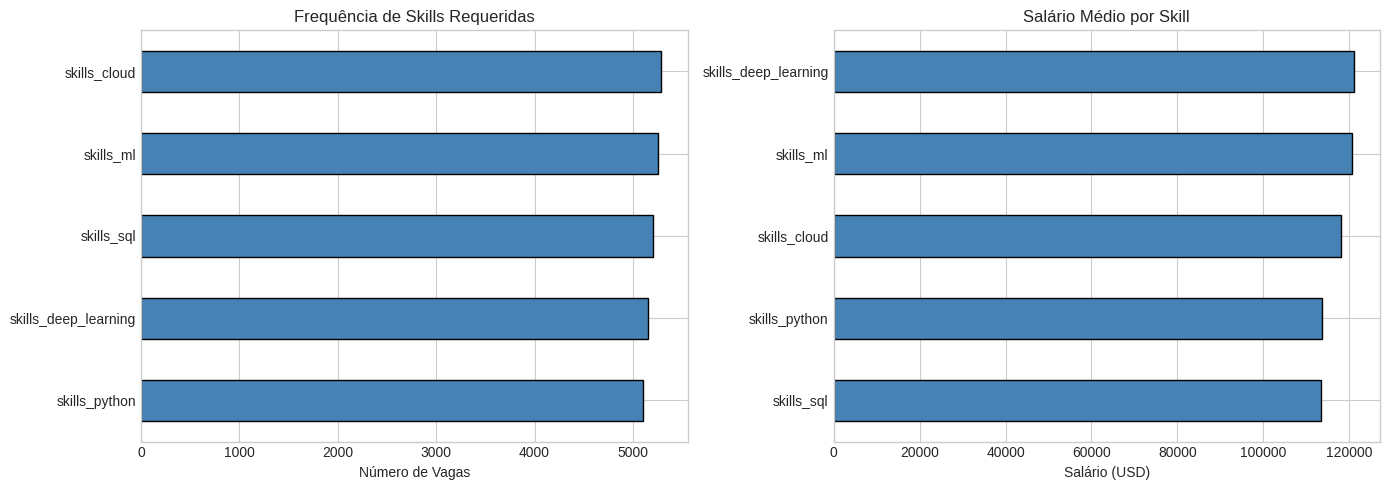

In [13]:
# Skills binárias
skills_cols = ['skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud']

# Frequência de cada skill
skills_freq = df[skills_cols].sum().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Frequência
skills_freq.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Frequência de Skills Requeridas')
axes[0].set_xlabel('Número de Vagas')

# Impacto no salário
skill_salary = {}
for skill in skills_cols:
    skill_salary[skill] = df[df[skill] == 1]['salary'].mean()

pd.Series(skill_salary).sort_values(ascending=True).plot(
    kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Salário Médio por Skill')
axes[1].set_xlabel('Salário (USD)')

plt.tight_layout()
plt.savefig('../reports/skills_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.6 Matriz de Correlação

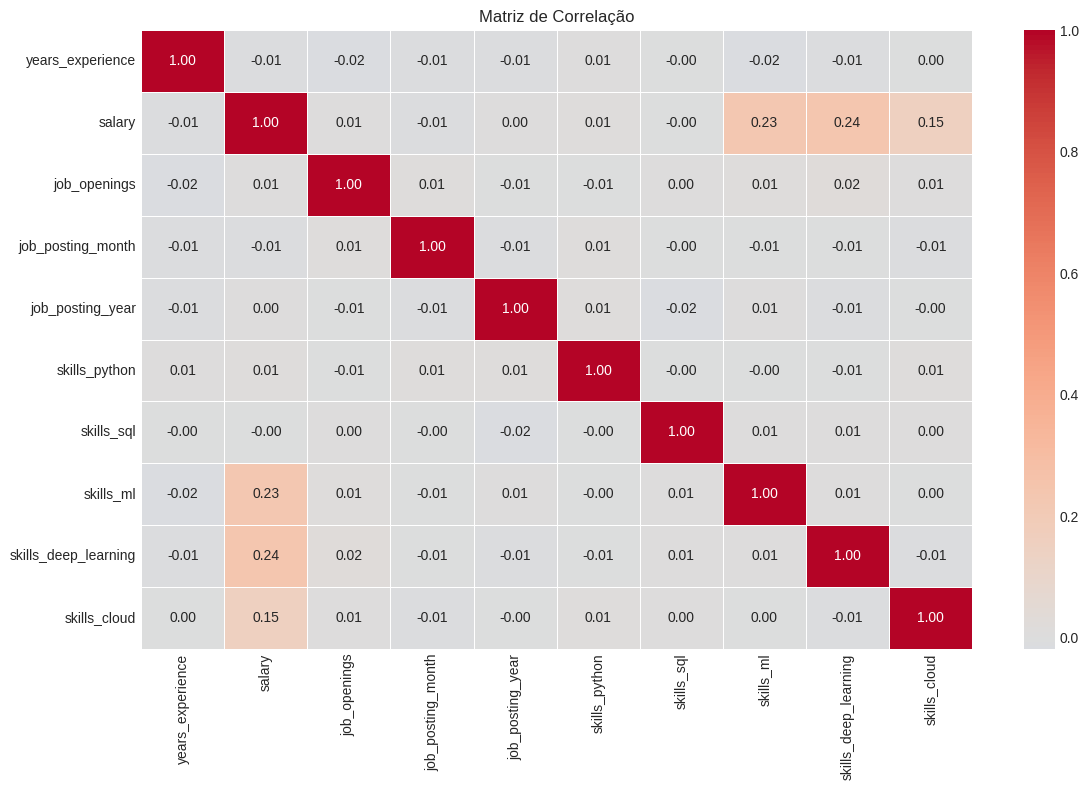

In [14]:
# Selecionar apenas colunas numéricas
numeric_cols = ['years_experience', 'salary', 'job_openings', 'job_posting_month', 'job_posting_year'] + skills_cols

# Matriz de correlação
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.savefig('../reports/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.7 Análise de Duplicatas

In [15]:
# Verificar duplicatas
duplicatas_total = df.duplicated().sum()
duplicatas_sem_id = df.drop(columns=['job_id']).duplicated().sum()

print("Análise de Duplicatas:")
print(f"  Linhas duplicadas (todas as colunas): {duplicatas_total}")
print(f"  Linhas duplicadas (excluindo job_id): {duplicatas_sem_id}")

if duplicatas_sem_id > 0:
    print(f"\n  ATENÇÃO: {duplicatas_sem_id} linhas duplicadas encontradas!")
    print("  Exemplos de duplicatas:")
    duplicadas = df[df.drop(columns=['job_id']).duplicated(keep=False)]
    print(duplicadas.head(10))
else:
    print("\n  ✓ Nenhuma duplicata encontrada no dataset.")

Análise de Duplicatas:
  Linhas duplicadas (todas as colunas): 0
  Linhas duplicadas (excluindo job_id): 0

  ✓ Nenhuma duplicata encontrada no dataset.


### 3.8 Análise de Outliers

Análise de Outliers (Método IQR):
         Variável  Outliers % do Total Limite Inferior Limite Superior
 years_experience         0      0.00%           -9.00           23.00
           salary         4      0.04%        21946.50       202662.50
     job_openings         0      0.00%           -3.00           13.00
job_posting_month         0      0.00%           -5.00           19.00
 job_posting_year         0      0.00%         2015.00         2031.00


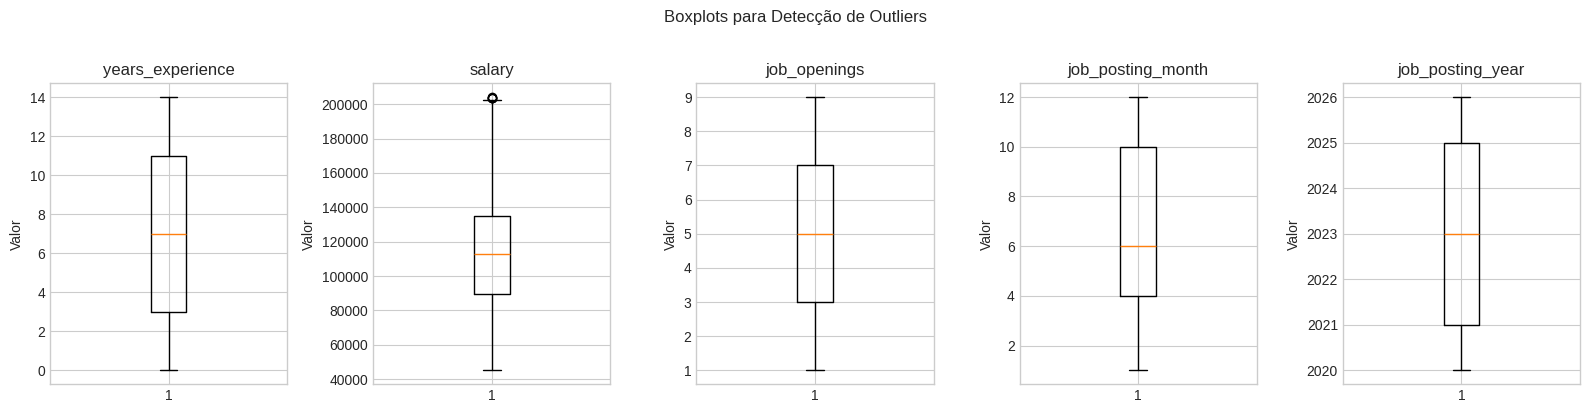


✓ Nota: Neste dataset, os outliers detectados pelo IQR são valores
  dentro de faixas razoáveis e não serão removidos.


In [16]:
# Análise de outliers usando método IQR
def detect_outliers_iqr(data, column):
    """Detecta outliers usando o método IQR (Interquartile Range)."""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Variáveis numéricas para análise de outliers
numeric_for_outliers = ['years_experience', 'salary', 'job_openings', 'job_posting_month', 'job_posting_year']

print("Análise de Outliers (Método IQR):")
print("="*60)

outlier_summary = []
for col in numeric_for_outliers:
    n_outliers, lower, upper = detect_outliers_iqr(df, col)
    pct = (n_outliers / len(df)) * 100
    outlier_summary.append({
        'Variável': col,
        'Outliers': n_outliers,
        '% do Total': f"{pct:.2f}%",
        'Limite Inferior': f"{lower:.2f}",
        'Limite Superior': f"{upper:.2f}"
    })
    
outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

# Visualização de outliers com boxplots
fig, axes = plt.subplots(1, len(numeric_for_outliers), figsize=(16, 4))
for i, col in enumerate(numeric_for_outliers):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Valor')

plt.suptitle('Boxplots para Detecção de Outliers', y=1.02)
plt.tight_layout()
plt.savefig('../reports/outliers_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Nota: Neste dataset, os outliers detectados pelo IQR são valores")
print("  dentro de faixas razoáveis e não serão removidos.")

### 3.9 Análise de Multicolinearidade (VIF)

Análise de Multicolinearidade - VIF (Variance Inflation Factor)

Resultados:
            Variável  VIF Interpretação
    years_experience  1.0         Baixa
        job_openings  1.0         Baixa
   job_posting_month  1.0         Baixa
    job_posting_year  1.0         Baixa
       skills_python  1.0         Baixa
          skills_sql  1.0         Baixa
           skills_ml  1.0         Baixa
skills_deep_learning  1.0         Baixa
        skills_cloud  1.0         Baixa


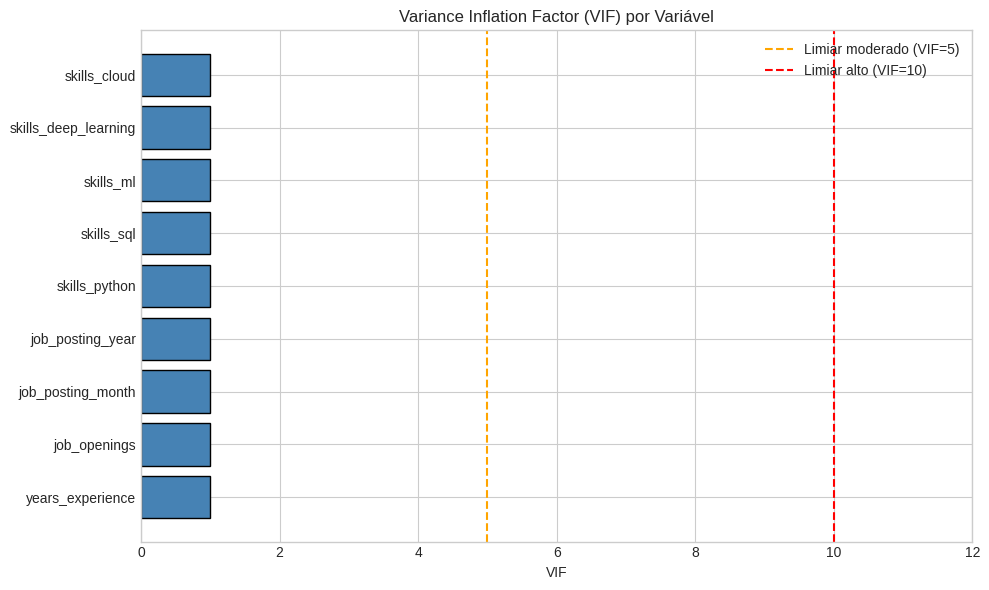


✓ Nenhuma variável apresenta multicolinearidade problemática (VIF < 5).


In [17]:
from statsmodels.tools.tools import add_constant

# Selecionar variáveis numéricas e binárias
numeric_cols_vif = ['years_experience', 'job_openings', 'job_posting_month', 'job_posting_year',
                    'skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud']

# Criar matriz com a constante indispensável para o cálculo correto no statsmodels
X_vif_with_const = add_constant(df[numeric_cols_vif])

# Calcular VIF para cada variável
vif_data = []
for col in numeric_cols_vif:
    idx = list(X_vif_with_const.columns).index(col)
    vif_value = variance_inflation_factor(X_vif_with_const.values, idx)
    vif_data.append({
        'Variável': col,
        'VIF': round(vif_value, 2),
        'Interpretação': 'Alta' if vif_value > 10 else ('Moderada' if vif_value > 5 else 'Baixa')
    })

vif_df = pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

print("Análise de Multicolinearidade - VIF (Variance Inflation Factor)")
print("="*65)
print("\nResultados:")
print(vif_df.to_string(index=False))

# Visualização
plt.figure(figsize=(10, 6))
colors = ['red' if v > 10 else ('orange' if v > 5 else 'steelblue') for v in vif_df['VIF']]
plt.barh(vif_df['Variável'], vif_df['VIF'], color=colors, edgecolor='black')
plt.axvline(x=5, color='orange', linestyle='--', label='Limiar moderado (VIF=5)')
plt.axvline(x=10, color='red', linestyle='--', label='Limiar alto (VIF=10)')
plt.xlim(0, 12)
plt.xlabel('VIF')
plt.title('Variance Inflation Factor (VIF) por Variável')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/vif_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Conclusão
high_vif = vif_df[vif_df['VIF'] > 5]
if len(high_vif) > 0:
    print(f"\n⚠ Variáveis com VIF > 5: {list(high_vif['Variável'])}")
else:
    print("\n✓ Nenhuma variável apresenta multicolinearidade problemática (VIF < 5).")

---
## 4. Pré-processamento

### 4.1 Definição de Variáveis

In [18]:
# Remover job_id (identificador)
df_model = df.drop(columns=['job_id'])

# Definir X e y
X = df_model.drop(columns=['salary'])

#Discretiza salary em classes
y_c = pd.qcut(df_model['salary'], q=3, labels=['Baixo', 'Medio', 'Alto'])

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_c)

# Aplicar mapeamento ordinal manual (0=Baixo, 1=Medio, 2=Alto)
target_mapping = {'Baixo': 0, 'Medio': 1, 'Alto': 2}
y = y_c.map(target_mapping).astype(int)

# Salvar artefato de mapeamento para pós-processamento de inferências
joblib.dump(target_mapping, '../artifacts/target_mapping.pkl')

print('Mapeamento de classes:')

for i, class_name in enumerate(label_encoder.classes_):
    print(f"{i} = {class_name}")

print(f"Features (X): {X.shape}")
print(f"Target (y): {y.shape}")
print(f"Target (y) unique: {np.unique(y)}")

Mapeamento de classes:
0 = Alto
1 = Baixo
2 = Medio
Features (X): (10345, 17)
Target (y): (10345,)
Target (y) unique: [0 1 2]


In [19]:
# Classificar as variáveis
# Variáveis numéricas (para padronização)
numeric_features = ['years_experience', 'job_posting_month', 'job_posting_year', 'job_openings']

# Variáveis binárias (já são 0/1)
binary_features = ['skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud']

# Variáveis ordinais (têm ordem natural)
ordinal_features = ['experience_level', 'education_level', 'hiring_urgency']

# Variáveis nominais (sem ordem - One-Hot)
nominal_features = ['job_title', 'company_size', 'company_industry', 'country', 'remote_type']

print("Variáveis por tipo:")
print(f"  Numéricas: {numeric_features}")
print(f"  Binárias: {binary_features}")
print(f"  Ordinais: {ordinal_features}")
print(f"  Nominais: {nominal_features}")

Variáveis por tipo:
  Numéricas: ['years_experience', 'job_posting_month', 'job_posting_year', 'job_openings']
  Binárias: ['skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud']
  Ordinais: ['experience_level', 'education_level', 'hiring_urgency']
  Nominais: ['job_title', 'company_size', 'company_industry', 'country', 'remote_type']


### 4.2 Engenharia de Recursos (Feature Engineering)

In [20]:
# Criar a variável derivada 'total_skills'
# Justificativa: Profissionais com maior diversidade técnica tendem a alcançar faixas salariais superiores.
skills_cols = ['skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud']
X['total_skills'] = X[skills_cols].sum(axis=1)

print("Atributo derivado 'total_skills' criado com sucesso.")
print(f"Dimensão atualizada de X: {X.shape}")

Atributo derivado 'total_skills' criado com sucesso.
Dimensão atualizada de X: (10345, 18)


### 4.3 Pipeline de Pré-processamento

In [21]:
# Mapeamento das variaveis
numeric_features = ['years_experience', 'job_posting_month', 'job_posting_year', 'job_openings', 'total_skills']
binary_features = ['skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud']
ordinal_features = ['experience_level', 'education_level', 'hiring_urgency']
nominal_features = ['job_title', 'company_size', 'company_industry', 'country', 'remote_type']

# Definir ordens para variáveis ordinais
experience_order = ['Entry', 'Mid', 'Senior']
education_order = ['Bachelor', 'Master', 'PhD']
urgency_order = ['Low', 'Medium', 'High']

# Preprocessador
preprocessor = ColumnTransformer(
    transformers=[
        # Numéricas: StandardScaler
        ('num', StandardScaler(), numeric_features),
        
        # Binárias: manter como estão (passthrough)
        ('bin', 'passthrough', binary_features),
        
        # Ordinais: OrdinalEncoder
        ('ord', OrdinalEncoder(categories=[experience_order, education_order, urgency_order]), 
         ordinal_features),
        
        # Nominais: OneHotEncoder
        ('nom', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), 
         nominal_features)
    ],
    remainder='drop'
)

print("Preprocessador criado!")

Preprocessador criado!


### 4.4 Divisão dos Dados

In [22]:
# Split treino/teste (60/20/20)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=SEED, stratify=y
)
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print(f"Treino:    {X_train.shape[0]:,} amostras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Validação: {X_validation.shape[0]:,} amostras ({X_validation.shape[0]/len(X)*100:.0f}%)")
print(f"Teste:     {X_test.shape[0]:,} amostras ({X_test.shape[0]/len(X)*100:.0f}%)")

Treino:    6,207 amostras (60%)
Validação: 2,069 amostras (20%)
Teste:     2,069 amostras (20%)


In [23]:
# Aplicar preprocessamento
X_train_processed = preprocessor.fit_transform(X_train)
X_validation_processed = preprocessor.transform(X_validation)
X_test_processed = preprocessor.transform(X_test)

print(f"Shape após preprocessamento:")
print(f"  X_train:      {X_train_processed.shape}")
print(f"  X_validation: {X_validation_processed.shape}")
print(f"  X_test:       {X_test_processed.shape}")

Shape após preprocessamento:
  X_train:      (6207, 34)
  X_validation: (2069, 34)
  X_test:       (2069, 34)


In [24]:
# Salvar preprocessador
joblib.dump(preprocessor, '../artifacts/preprocessor.joblib')
print("Preprocessador salvo em: artifacts/preprocessor.joblib")

Preprocessador salvo em: artifacts/preprocessor.joblib


---
## 5. Modelagem Supervisionada

### 5.1 Função de Avaliação

In [25]:
def evaluate_model(model, X_train, X_val, X_test, y_train, y_val, y_test, model_name):
    """
    Avalia um modelo de classificação em treino, validação e teste.
    """
    # Previsões
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    
    # Métricas de treino
    train_acc = accuracy_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred, average='macro')
    
    # Métricas de validação
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average='macro')
    
    # Métricas de teste
    test_acc = accuracy_score(y_test, y_test_pred)
    test_bal_acc = balanced_accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, average='macro', zero_division = 0)
    test_recall = recall_score(y_test, y_test_pred, average='macro', zero_division = 0)
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    
    print(f"\n{'='*50}")
    print(f"Modelo: {model_name}")
    print(f"{'='*50}")
    print(f"\nTREINO:")
    print(f"  Acurácia: {train_acc:.4f}")
    print(f"  F1-macro: {train_f1:.4f}")
    print(f"\nVALIDAÇÃO:")
    print(f"  Acurácia: {val_acc:.4f}")
    print(f"  F1-macro: {val_f1:.4f}")
    print(f"\nTESTE:")
    print(f"  Acurácia:          {test_acc:.4f}")
    print(f"  Acurácia Balanc.:  {test_bal_acc:.4f}")
    print(f"  Precisão (macro):  {test_precision:.4f}")
    print(f"  Revocação (macro): {test_recall:.4f}")
    print(f"  F1-Score (macro):  {test_f1:.4f}")
    
    return {
        'model_name': model_name,
        'train_accuracy': train_acc,
        'train_f1_macro': train_f1,
        'val_accuracy': val_acc,
        'val_f1_macro': val_f1,
        'test_accuracy': test_acc,
        'test_balanced_accuracy': test_bal_acc,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1_macro': test_f1
    }

### 5.2 Modelo 1: Baseline (Classe Majoritária)

In [26]:
    baseline_model = DummyClassifier(strategy="most_frequent", random_state=SEED)
    baseline_model.fit(X_train_processed, y_train)

    baseline_results = evaluate_model(
        baseline_model, 
        X_train_processed, X_validation_processed,X_test_processed,  # X_test vem antes
        y_train, y_validation, y_test, 
        'Baseline (Majoritária)'
    )


Modelo: Baseline (Majoritária)

TREINO:
  Acurácia: 0.3335
  F1-macro: 0.1667

VALIDAÇÃO:
  Acurácia: 0.3335
  F1-macro: 0.1667

TESTE:
  Acurácia:          0.3330
  Acurácia Balanc.:  0.3333
  Precisão (macro):  0.1110
  Revocação (macro): 0.3333
  F1-Score (macro):  0.1665


### 5.3 Modelo 2: Modelo Linear (Logistic Regression)

In [27]:
# Treinar modelo
lr_model = LogisticRegression(random_state=SEED, max_iter=1000)
lr_model.fit(X_train_processed, y_train)

lr_results = evaluate_model(lr_model, X_train_processed, X_validation_processed, X_test_processed,
                            y_train, y_validation, y_test, 'Logistic Regression')


Modelo: Logistic Regression

TREINO:
  Acurácia: 0.9383
  F1-macro: 0.9387

VALIDAÇÃO:
  Acurácia: 0.9319
  F1-macro: 0.9324

TESTE:
  Acurácia:          0.9323
  Acurácia Balanc.:  0.9323
  Precisão (macro):  0.9367
  Revocação (macro): 0.9323
  F1-Score (macro):  0.9332


### 5.4 Modelo 3: Random Forest

In [28]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=SEED,
    n_jobs=-1
)
rf_model.fit(X_train_processed, y_train)

rf_results = evaluate_model(rf_model, X_train_processed, X_validation_processed, X_test_processed,y_train, y_validation, y_test, "Random Forest")


Modelo: Random Forest

TREINO:
  Acurácia: 0.9457
  F1-macro: 0.9456

VALIDAÇÃO:
  Acurácia: 0.8400
  F1-macro: 0.8394

TESTE:
  Acurácia:          0.8531
  Acurácia Balanc.:  0.8531
  Precisão (macro):  0.8584
  Revocação (macro): 0.8531
  F1-Score (macro):  0.8525


### 5.5 Modelo 4: XGBoost

In [29]:
# Treinar modelo
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=SEED,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb_model.fit(X_train_processed, y_train)

# Avaliar
xgb_results = evaluate_model(xgb_model, X_train_processed, X_validation_processed, X_test_processed, 
                             y_train, y_validation,y_test, 'XGBoost')


Modelo: XGBoost

TREINO:
  Acurácia: 0.9791
  F1-macro: 0.9791

VALIDAÇÃO:
  Acurácia: 0.9280
  F1-macro: 0.9284

TESTE:
  Acurácia:          0.9333
  Acurácia Balanc.:  0.9333
  Precisão (macro):  0.9352
  Revocação (macro): 0.9333
  F1-Score (macro):  0.9338


In [30]:
print("lr_results:", lr_results)
print("rf_results:", rf_results)
print("xgb_results:", xgb_results)

lr_results: {'model_name': 'Logistic Regression', 'train_accuracy': 0.9382954728532302, 'train_f1_macro': np.float64(0.9387144657327685), 'val_accuracy': 0.931851135814403, 'val_f1_macro': np.float64(0.9324118262297479), 'test_accuracy': 0.9323344610923151, 'test_balanced_accuracy': np.float64(0.9323327934484621), 'test_precision': np.float64(0.9366929704739801), 'test_recall': np.float64(0.9323327934484621), 'test_f1_macro': np.float64(0.9331742846459328)}
rf_results: {'model_name': 'Random Forest', 'train_accuracy': 0.9457064604478814, 'train_f1_macro': np.float64(0.945637315155858), 'val_accuracy': 0.8400193330111165, 'val_f1_macro': np.float64(0.8393882621934182), 'test_accuracy': 0.8530691155147414, 'test_balanced_accuracy': np.float64(0.8531148552477511), 'test_precision': np.float64(0.8584083625981759), 'test_recall': np.float64(0.8531148552477511), 'test_f1_macro': np.float64(0.8525406329222021)}
xgb_results: {'model_name': 'XGBoost', 'train_accuracy': 0.9790559046238119, 'trai

### 5.6 Comparação dos Modelos

In [31]:
# Criar DataFrame com resultados
results_df = pd.DataFrame([baseline_results, lr_results, rf_results, xgb_results])
results_df = results_df.set_index('model_name')

print("\nComparação dos Modelos:")
print(results_df.round(3))


Comparação dos Modelos:
                        train_accuracy  train_f1_macro  val_accuracy  \
model_name                                                             
Baseline (Majoritária)           0.333           0.167         0.333   
Logistic Regression              0.938           0.939         0.932   
Random Forest                    0.946           0.946         0.840   
XGBoost                          0.979           0.979         0.928   

                        val_f1_macro  test_accuracy  test_balanced_accuracy  \
model_name                                                                    
Baseline (Majoritária)         0.167          0.333                   0.333   
Logistic Regression            0.932          0.932                   0.932   
Random Forest                  0.839          0.853                   0.853   
XGBoost                        0.928          0.933                   0.933   

                        test_precision  test_recall  test_f1_macro 

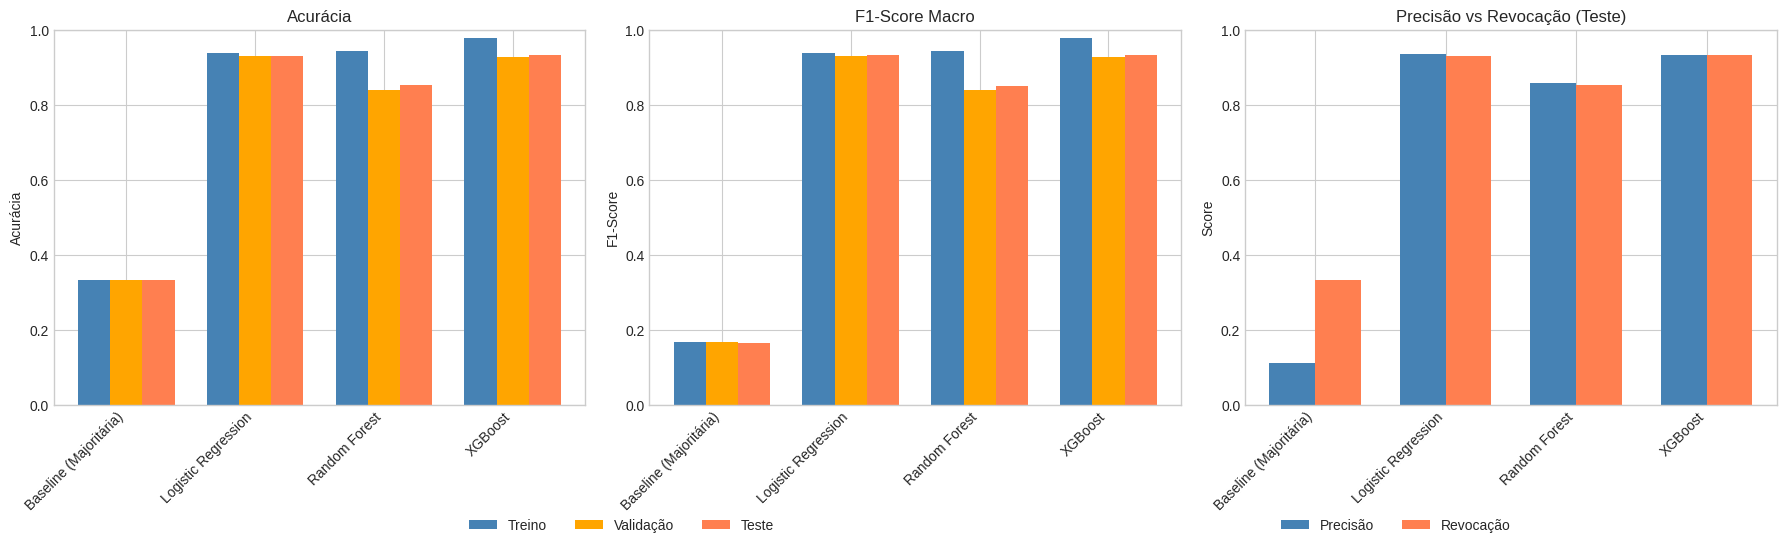

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = results_df.index.tolist()
x = np.arange(len(models))
width = 0.25

# Acurácia
axes[0].bar(x - width, results_df['train_accuracy'], width, label='Treino', color='steelblue')
axes[0].bar(x, results_df['val_accuracy'], width, label='Validação', color='orange')
axes[0].bar(x + width, results_df['test_accuracy'], width, label='Teste', color='coral')
axes[0].set_title('Acurácia')
axes[0].set_ylabel('Acurácia')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].set_ylim(0, 1)

# F1-Score
axes[1].bar(x - width, results_df['train_f1_macro'], width, label='Treino', color='steelblue')
axes[1].bar(x, results_df['val_f1_macro'], width, label='Validação', color='orange')
axes[1].bar(x + width, results_df['test_f1_macro'], width, label='Teste', color='coral')
axes[1].set_title('F1-Score Macro')
axes[1].set_ylabel('F1-Score')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].set_ylim(0, 1)

# Precisão vs Revocação (Teste)
width2 = 0.35
axes[2].bar(x - width2/2, results_df['test_precision'], width2, label='Precisão', color='steelblue')
axes[2].bar(x + width2/2, results_df['test_recall'], width2, label='Revocação', color='coral')
axes[2].set_title('Precisão vs Revocação (Teste)')
axes[2].set_ylabel('Score')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=45, ha='right')
axes[2].set_ylim(0, 1)

# Legendas
from matplotlib.patches import Patch
legend1 = [Patch(facecolor='steelblue', label='Treino'),
           Patch(facecolor='orange', label='Validação'),
           Patch(facecolor='coral', label='Teste')]

fig.legend(handles=legend1, loc='lower center', ncol=3, bbox_to_anchor=(0.35, -0.1))

legend2 = [Patch(facecolor='steelblue', label='Precisão'),
           Patch(facecolor='coral', label='Revocação')]
fig.legend(handles=legend2, loc='lower center', ncol=2, bbox_to_anchor=(0.78, -0.1))

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig('../reports/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.7 Validação cruzada com média e desvio-padrão (Conjunto de Treino)

In [33]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Lista de modelos para comparar
models = {
    'Baseline (Majoritária)': DummyClassifier(strategy='most_frequent', random_state=SEED),
    'Logistic Regression': LogisticRegression(random_state=SEED, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=SEED, n_jobs=-1, eval_metric='mlogloss')
}

cv_results = []
for name, model in models.items():
    scores = cross_val_score(model, X_train_processed, y_train, cv=skf, scoring='f1_macro')
    media = np.mean(scores)
    desvio = np.std(scores)
    print(f"{name}: F1-macro = {media:.4f} (+/- {desvio:.4f})")
    cv_results.append({'Modelo': name, 'F1_mean': media, 'F1_std': desvio})

cv_df = pd.DataFrame(cv_results)
print("\n", cv_df)

Baseline (Majoritária): F1-macro = 0.1667 (+/- 0.0000)
Logistic Regression: F1-macro = 0.9342 (+/- 0.0053)
Random Forest: F1-macro = 0.8423 (+/- 0.0142)
XGBoost: F1-macro = 0.9293 (+/- 0.0038)

                    Modelo   F1_mean    F1_std
0  Baseline (Majoritária)  0.166727  0.000049
1     Logistic Regression  0.934242  0.005350
2           Random Forest  0.842338  0.014163
3                 XGBoost  0.929299  0.003835


### 5.8 Matriz de Confusão $K \times K$ ($3 \times 3$)

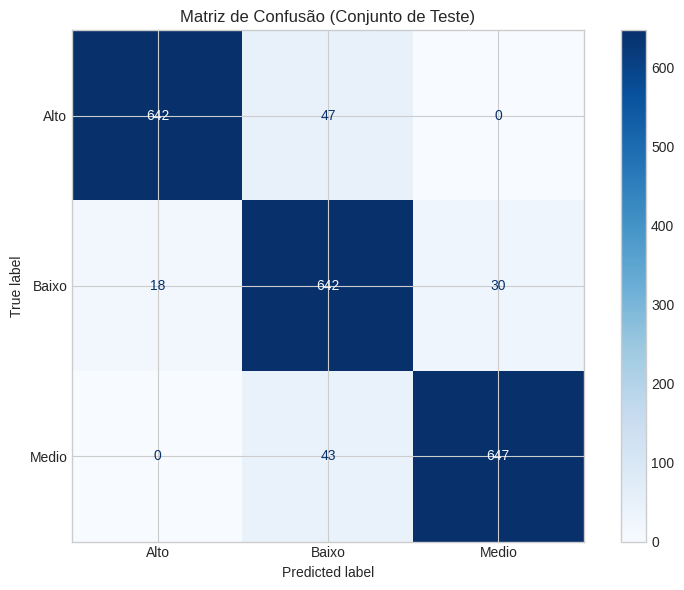


Matriz de Confusão:
       Alto  Baixo  Medio
Alto    642     47      0
Baixo    18    642     30
Medio     0     43    647


In [34]:
# Escolher o melhor modelo (ex: XGBoost)
best_model = xgb_model  # ou rf_model, lr_model

# Previsões no conjunto de TESTE
y_test_pred = best_model.predict(X_test_processed)

# Matriz de confusão
cm = confusion_matrix(y_test, y_test_pred)

# Nomes das classes
class_names = label_encoder.classes_  # ['Alto', 'Baixo', 'Medio']

# Visualização
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Matriz de Confusão (Conjunto de Teste)')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Exibir valores
print("\nMatriz de Confusão:")
print(pd.DataFrame(cm, index=class_names, columns=class_names))

### 5.9 Curva ROC One-vs-Rest (OvR)

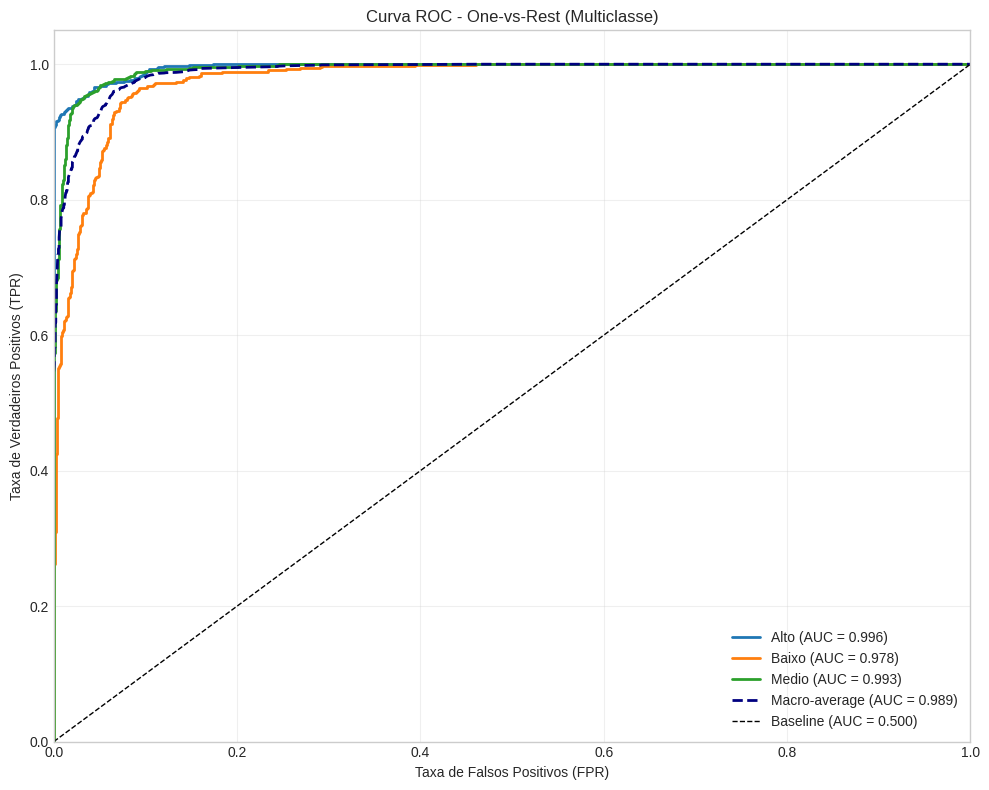


AUC por classe:
  Alto: 0.9956
  Baixo: 0.9778
  Medio: 0.9927

AUC Macro: 0.9889


In [35]:
# Binarizar y_test para OvR (3 classes)
n_classes = len(label_encoder.classes_)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Obter probabilidades do melhor modelo
best_model = xgb_model  # ou rf_model, lr_model
y_score = best_model.predict_proba(X_test_processed)

# Calcular ROC para cada classe
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calcular ROC macro (média)
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
roc_auc_macro = auc(all_fpr, mean_tpr)

# Plot
plt.figure(figsize=(10, 8))

# Curva de cada classe
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
class_names = label_encoder.classes_

for i, color in enumerate(colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')

# Curva macro média
plt.plot(all_fpr, mean_tpr, color='navy', lw=2, linestyle='--',
         label=f'Macro-average (AUC = {roc_auc_macro:.3f})')

# Linha diagonal (baseline)
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Baseline (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva ROC - One-vs-Rest (Multiclasse)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/roc_curve_ovr.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAUC por classe:")
for i, name in enumerate(class_names):
    print(f"  {name}: {roc_auc[i]:.4f}")
print(f"\nAUC Macro: {roc_auc_macro:.4f}")

---
## 6. Otimização de Hiperparâmetros

### 6.1 GridSeachCV no Random Forest

In [36]:
# GridSearchCV no Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("Iniciando GridSearchCV...")
print(f"Total de combinações: {3 * 4 * 3 * 3} = 108")

grid_start = time.time()

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_processed, y_train)

grid_time = time.time() - grid_start


print(f"\nGridSearchCV concluído em {grid_time:.2f} segundos!")

Iniciando GridSearchCV...
Total de combinações: 108 = 108
Fitting 5 folds for each of 108 candidates, totalling 540 fits

GridSearchCV concluído em 20.53 segundos!


In [37]:
# Melhores parâmetros
print("Melhores hiperparâmetros:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nMelhor RMSE (CV): ${-grid_search.best_score_:,.2f}")

Melhores hiperparâmetros:
  max_depth: None
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 200

Melhor RMSE (CV): $-0.90


In [38]:
# Avaliar modelo otimizado
best_rf_model = grid_search.best_estimator_

# Avaliar modelo otimizado (Correção na passagem de parâmetros)
best_rf_results = evaluate_model(
    best_rf_model, 
    X_train_processed, 
    X_validation_processed, # Faltava a validação
    X_test_processed, 
    y_train, 
    y_validation,           # Faltava a validação
    y_test, 
    'Random Forest (Otimizado)'
)


Modelo: Random Forest (Otimizado)

TREINO:
  Acurácia: 1.0000
  F1-macro: 1.0000

VALIDAÇÃO:
  Acurácia: 0.8951
  F1-macro: 0.8950

TESTE:
  Acurácia:          0.9029
  Acurácia Balanc.:  0.9029
  Precisão (macro):  0.9033
  Revocação (macro): 0.9029
  F1-Score (macro):  0.9028


In [39]:
# Salvar melhor modelo
joblib.dump(best_rf_model, '../models/best_random_forest.joblib')
print("Modelo salvo em: models/best_random_forest.joblib")

Modelo salvo em: models/best_random_forest.joblib


### 6.2 Features Importantes

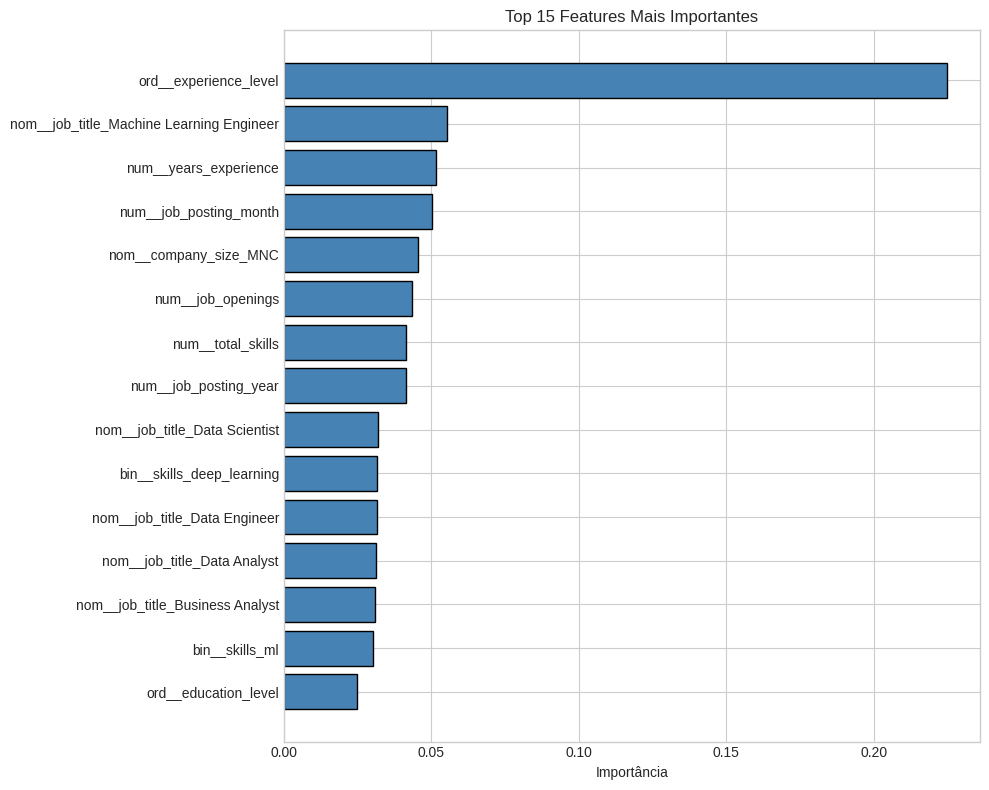

In [40]:
# Obter nomes das features após transformação
feature_names = preprocessor.get_feature_names_out()

# Feature importance
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': best_rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Top 15 features
plt.figure(figsize=(10, 8))
top_features = importance_df.head(15)
plt.barh(top_features['feature'], top_features['importance'], color='steelblue', edgecolor='black')
plt.xlabel('Importância')
plt.title('Top 15 Features Mais Importantes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Otimização Bayesiana (Optuna)

In [41]:
def objective(trial):
    """Função objetivo para Optuna."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_float('max_features', 0.1, 1.0),  # Contínuo!
        'random_state': SEED,
        'n_jobs': -1
    }
    
    model = RandomForestClassifier(**params)
    
    # Validação cruzada estratificada
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = cross_val_score(model, X_train_processed, y_train, cv=skf, scoring='f1_macro')
    
    return scores.mean()

print("="*60)
print("ESTRATÉGIA 2: Otimização Bayesiana (Optuna)")
print("="*60)
print("Espaço de busca:")
print("  n_estimators: [50, 200] (inteiro)")
print("  max_depth: [3, 20] (inteiro)")
print("  min_samples_split: [2, 15] (inteiro)")
print("  min_samples_leaf: [1, 10] (inteiro)")
print("  max_features: [0.1, 1.0] (contínuo)")
print(f"\nMáximo de avaliações: 50")

# Medir tempo
start_time_optuna = time.time()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=50, show_progress_bar=True)

optuna_time = time.time() - start_time_optuna

print(f"\n✓ Optuna concluído em {optuna_time:.2f} segundos")
print(f"\nMelhores hiperparâmetros:")
for param, value in study.best_params.items():
    print(f"  {param}: {value}")
print(f"\nMelhor F1-macro (CV): {study.best_value:.4f}")

ESTRATÉGIA 2: Otimização Bayesiana (Optuna)
Espaço de busca:
  n_estimators: [50, 200] (inteiro)
  max_depth: [3, 20] (inteiro)
  min_samples_split: [2, 15] (inteiro)
  min_samples_leaf: [1, 10] (inteiro)
  max_features: [0.1, 1.0] (contínuo)

Máximo de avaliações: 50


  0%|          | 0/50 [00:00<?, ?it/s]


✓ Optuna concluído em 73.72 segundos

Melhores hiperparâmetros:
  n_estimators: 182
  max_depth: 15
  min_samples_split: 6
  min_samples_leaf: 5
  max_features: 0.4137939963673701

Melhor F1-macro (CV): 0.9238


### 6.3 Comparação das Estratégias de Otimização

COMPARAÇÃO DAS ESTRATÉGIAS DE OTIMIZAÇÃO
         Estratégia  Melhor F1-macro Tempo (s)  Nº Ajustes Ganho vs Padrão
Configuração Padrão         0.888041         -           1               -
        Grid Search         0.895487     20.53         540          +0.74%
 Optuna (Bayesiana)         0.923810     73.72         250          +3.58%


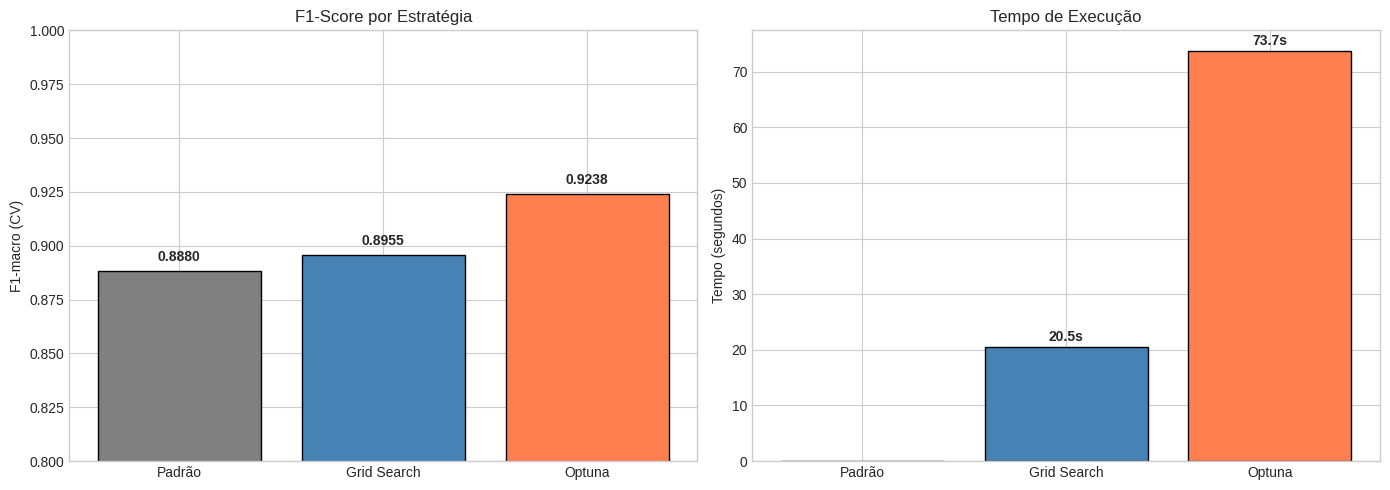

In [42]:
# Treinar modelo com configuração padrão (baseline)
rf_default = RandomForestClassifier(random_state=SEED, n_jobs=-1)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
default_scores = cross_val_score(rf_default, X_train_processed, y_train, cv=skf, scoring='f1_macro')
default_f1 = default_scores.mean()

# Resultados
comparison = pd.DataFrame({
    'Estratégia': ['Configuração Padrão', 'Grid Search', 'Optuna (Bayesiana)'],
    'Melhor F1-macro': [default_f1, grid_search.best_score_, study.best_value],
    'Tempo (s)': ['-', f'{grid_time:.2f}', f'{optuna_time:.2f}'],
    'Nº Ajustes': [1, 540, 50 * 5],  # 50 trials × 5 folds
    'Ganho vs Padrão': [
        '-',
        f'+{(grid_search.best_score_ - default_f1)*100:.2f}%',
        f'+{(study.best_value - default_f1)*100:.2f}%'
    ]
})

print("="*60)
print("COMPARAÇÃO DAS ESTRATÉGIAS DE OTIMIZAÇÃO")
print("="*60)
print(comparison.to_string(index=False))

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1-Score
strategies = ['Padrão', 'Grid Search', 'Optuna']
f1_scores = [default_f1, grid_search.best_score_, study.best_value]
colors = ['gray', 'steelblue', 'coral']

axes[0].bar(strategies, f1_scores, color=colors, edgecolor='black')
axes[0].set_ylabel('F1-macro (CV)')
axes[0].set_title('F1-Score por Estratégia')
axes[0].set_ylim(0.8, 1.0)
for i, v in enumerate(f1_scores):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontweight='bold')

# Tempo
times = [0, grid_time, optuna_time]
axes[1].bar(strategies, times, color=colors, edgecolor='black')
axes[1].set_ylabel('Tempo (segundos)')
axes[1].set_title('Tempo de Execução')
for i, v in enumerate(times):
    if v > 0:
        axes[1].text(i, v + 1, f'{v:.1f}s', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/optimization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Modelo Final Otimizado

In [43]:
# Usar melhores parâmetros (Optuna ou Grid, escolher o melhor)
if study.best_value >= grid_search.best_score_:
    print("Usando parâmetros do Optuna (melhor F1-macro)")
    best_params = study.best_params
else:
    print("Usando parâmetros do Grid Search (melhor F1-macro)")
    best_params = grid_search.best_params_

# Treinar modelo final
best_rf_model = RandomForestClassifier(**best_params, random_state=SEED, n_jobs=-1)
best_rf_model.fit(X_train_processed, y_train)

# Avaliar
best_rf_results = evaluate_model(
    best_rf_model, 
    X_train_processed, 
    X_validation_processed,
    X_test_processed, 
    y_train, 
    y_validation,
    y_test, 
    'Random Forest (Otimizado)'
)

# Salvar modelo
joblib.dump(best_rf_model, '../models/best_random_forest.joblib')
print("\n✓ Modelo salvo em: models/best_random_forest.joblib")

Usando parâmetros do Optuna (melhor F1-macro)

Modelo: Random Forest (Otimizado)

TREINO:
  Acurácia: 0.9609
  F1-macro: 0.9610

VALIDAÇÃO:
  Acurácia: 0.9227
  F1-macro: 0.9230

TESTE:
  Acurácia:          0.9299
  Acurácia Balanc.:  0.9299
  Precisão (macro):  0.9320
  Revocação (macro): 0.9299
  F1-Score (macro):  0.9304

✓ Modelo salvo em: models/best_random_forest.joblib


---
## 7. Modelagem Não Supervisionada

### 7.1 K-Means

Determinando número ótimo de clusters...


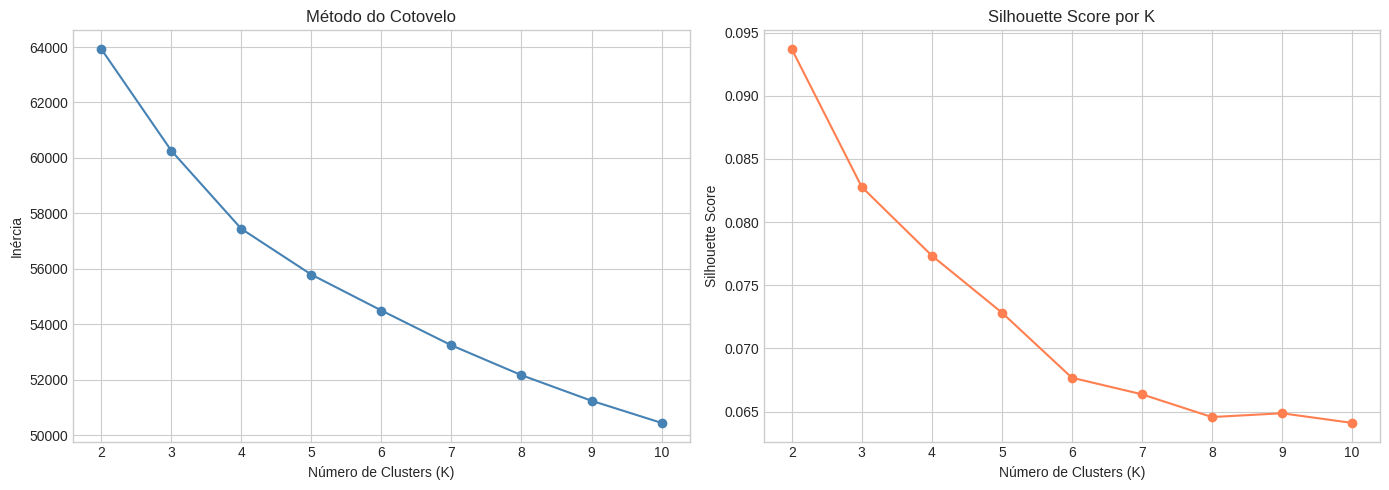


Melhor K pelo Silhouette: 2 (score: 0.0937)


In [44]:
# Transformer customizado para adicionar cluster como feature
class ClusterFeatureAdder(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=4, random_state=67):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.kmeans = None
    
    def fit(self, X, y=None):
        self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=10)
        self.kmeans.fit(X)
        return self
    
    def transform(self, X):
        clusters = self.kmeans.predict(X).reshape(-1, 1)
        return np.hstack([X, clusters])

# Determinar número ótimo de clusters (Elbow + Silhouette)
from sklearn.metrics import silhouette_score

print("Determinando número ótimo de clusters...")
silhouette_scores = []
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = kmeans_temp.fit_predict(X_train_processed)
    silhouette_scores.append(silhouette_score(X_train_processed, labels))
    inertias.append(kmeans_temp.inertia_)

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker='o', color='steelblue')
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inércia')
axes[0].set_title('Método do Cotovelo')
axes[0].set_xticks(K_range)

axes[1].plot(K_range, silhouette_scores, marker='o', color='coral')
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por K')
axes[1].set_xticks(K_range)

plt.tight_layout()
plt.savefig('../reports/cluster_selection.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = K_range[np.argmax(silhouette_scores)]
print(f"\nMelhor K pelo Silhouette: {best_k} (score: {max(silhouette_scores):.4f})")

### 7.2 Comparação: COM vs SEM cluster

In [45]:
N_CLUSTERS = best_k  # Usar o melhor K encontrado

# Adicionar cluster como feature
cluster_adder = ClusterFeatureAdder(n_clusters=N_CLUSTERS, random_state=SEED)
cluster_adder.fit(X_train_processed)

X_train_with_cluster = cluster_adder.transform(X_train_processed)
X_validation_with_cluster = cluster_adder.transform(X_validation_processed)
X_test_with_cluster = cluster_adder.transform(X_test_processed)

print(f"Shape original:    {X_train_processed.shape}")
print(f"Shape com cluster: {X_train_with_cluster.shape}")

# Comparação usando o melhor modelo (RandomForest otimizado)
from sklearn.model_selection import cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Modelo SEM cluster feature
rf_sem_cluster = RandomForestClassifier(**grid_search.best_params_, random_state=SEED, n_jobs=-1)
scores_sem = cross_val_score(rf_sem_cluster, X_train_processed, y_train, cv=skf, scoring='f1_macro')

# Modelo COM cluster feature (precisa re-treinar dentro do CV)
scores_com = []
for train_idx, val_idx in skf.split(X_train_processed, y_train):
    # Fit cluster apenas no fold de treino
    X_fold_train = X_train_processed[train_idx]
    X_fold_val = X_train_processed[val_idx]
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]
    
    # Adicionar cluster
    cluster_fold = ClusterFeatureAdder(n_clusters=N_CLUSTERS, random_state=SEED)
    cluster_fold.fit(X_fold_train)
    X_fold_train_c = cluster_fold.transform(X_fold_train)
    X_fold_val_c = cluster_fold.transform(X_fold_val)
    
    # Treinar e avaliar
    rf_com = RandomForestClassifier(**grid_search.best_params_, random_state=SEED, n_jobs=-1)
    rf_com.fit(X_fold_train_c, y_fold_train)
    y_pred = rf_com.predict(X_fold_val_c)
    scores_com.append(f1_score(y_fold_val, y_pred, average='macro'))

scores_com = np.array(scores_com)

# Resultados
print("\n" + "="*60)
print("COMPARAÇÃO: COM vs SEM CLUSTER FEATURE")
print("="*60)
print(f"\nSEM Cluster:")
print(f"  F1-macro (CV): {scores_sem.mean():.4f} (+/- {scores_sem.std()*2:.4f})")
print(f"\nCOM Cluster (K={N_CLUSTERS}):")
print(f"  F1-macro (CV): {scores_com.mean():.4f} (+/- {scores_com.std()*2:.4f})")

diferenca = (scores_com.mean() - scores_sem.mean()) * 100
print(f"\nDiferença: {diferenca:+.2f}%")

if diferenca > 0:
    print("→ Cluster MELHORA o desempenho")
else:
    print("→ Cluster NÃO melhora o desempenho (resultado negativo válido)")

Shape original:    (6207, 34)
Shape com cluster: (6207, 35)

COMPARAÇÃO: COM vs SEM CLUSTER FEATURE

SEM Cluster:
  F1-macro (CV): 0.8955 (+/- 0.0134)

COM Cluster (K=2):
  F1-macro (CV): 0.8900 (+/- 0.0106)

Diferença: -0.54%
→ Cluster NÃO melhora o desempenho (resultado negativo válido)


### 7.3 Vizualização dos Clusters

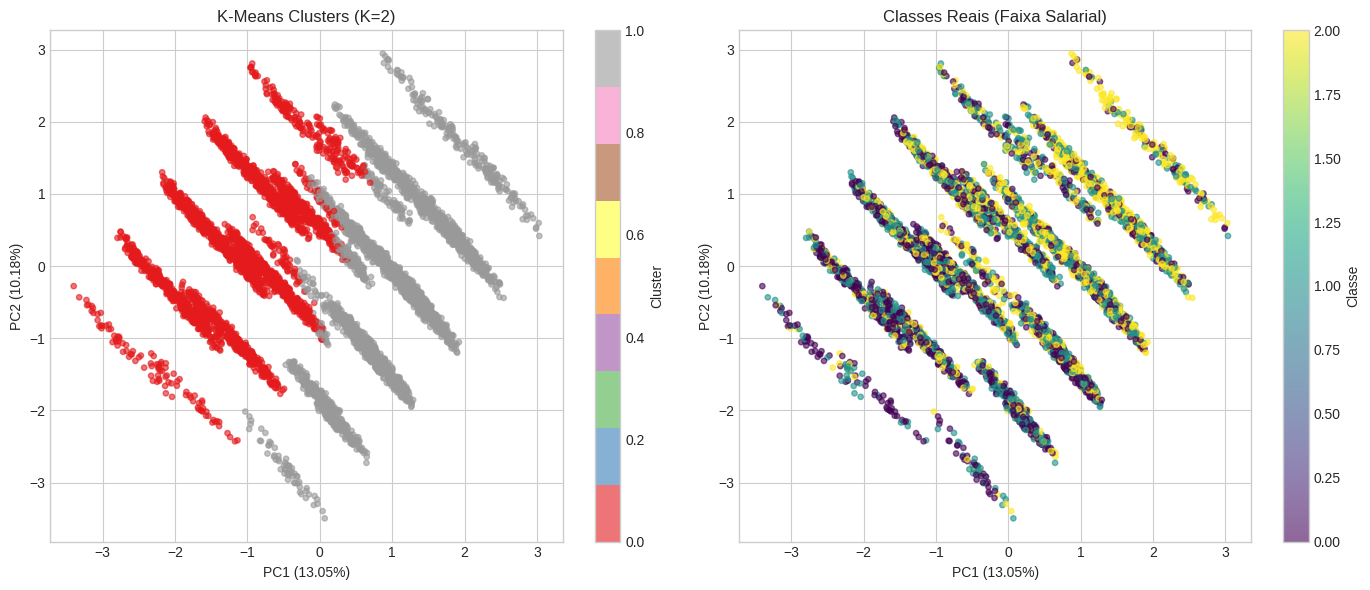


Distribuição de Classes por Cluster:
salary     0     1     2   All
row_0                         
0       1183  1054   791  3028
1        887  1014  1278  3179
All     2070  2068  2069  6207

Modelos não supervisionados salvos!


In [47]:
# PCA 2D para visualização
pca_2d = PCA(n_components=2, random_state=SEED)
X_pca_2d = pca_2d.fit_transform(X_train_processed)

# Clusters finais
kmeans_final = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
clusters = kmeans_final.fit_predict(X_train_processed)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Por cluster
scatter1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=clusters, cmap='Set1', alpha=0.6, s=15)
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
axes[0].set_title(f'K-Means Clusters (K={N_CLUSTERS})')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Por classe real
scatter2 = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_train, cmap='viridis', alpha=0.6, s=15)
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%})')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%})')
axes[1].set_title('Classes Reais (Faixa Salarial)')
plt.colorbar(scatter2, ax=axes[1], label='Classe')

plt.tight_layout()
plt.savefig('../reports/clusters_vs_classes.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabela de correspondência cluster vs classe
print("\nDistribuição de Classes por Cluster:")
cluster_class_dist = pd.crosstab(clusters, y_train, margins=True)
print(cluster_class_dist)

# Salvar modelo
joblib.dump(kmeans_final, '../models/kmeans_integrated.joblib')
joblib.dump(pca_2d, '../artifacts/pca_2d.joblib')
print("\nModelos não supervisionados salvos!")

---
## 8. Conclusões

In [46]:
# Resumo final dos resultados
print("="*60)
print("RESUMO DO PROJETO")
print("="*60)

print("\n1. DATASET")
print(f"   - Total de registros: {len(df):,}")
print(f"   - Total de features: {X.shape[1]}")
print(f"   - Features após encoding: {X_train_processed.shape[1]}")

print("\n2. MODELAGEM SUPERVISIONADA")
print(f"   Melhor modelo: Random Forest (Otimizado)")
print(f"   - RMSE (teste): ${best_rf_results['test_rmse']:,.2f}")
print(f"   - MAE (teste):  ${best_rf_results['test_mae']:,.2f}")
print(f"   - R² (teste):   {best_rf_results['test_r2']:.4f}")

print("\n3. MODELAGEM NÃO SUPERVISIONADA")
print(f"   - PCA: {n_components_95} componentes para 95% da variância")
print(f"   - K-Means: {N_CLUSTERS} clusters identificados")

print("\n4. ARTEFATOS SALVOS")
print("   - models/best_random_forest.joblib")
print("   - models/kmeans_model.joblib")
print("   - artifacts/preprocessor.joblib")
print("   - artifacts/pca_2d.joblib")
print("   - reports/*.png (gráficos)")

RESUMO DO PROJETO

1. DATASET
   - Total de registros: 10,345
   - Total de features: 18
   - Features após encoding: 34

2. MODELAGEM SUPERVISIONADA
   Melhor modelo: Random Forest (Otimizado)


KeyError: 'test_rmse'

In [ ]:
# Validação cruzada final do melhor modelo
print("\nValidação Cruzada (5-fold) do Melhor Modelo:")
cv_scores = cross_val_score(best_rf_model, X_train_processed, y_train, 
                            cv=5, scoring='neg_root_mean_squared_error')
print(f"  RMSE médio: ${-cv_scores.mean():,.2f} (+/- ${cv_scores.std() * 2:,.2f})")

### Limitações e Próximos Passos

**Limitações identificadas:**
1. Dataset possivelmente sintético (valores muito regulares, anos futuros como 2026)
2. Inconsistências nos dados (Entry-level com 14 anos de experiência)
3. Não há informações sobre benefícios, localização específica ou tipo de contrato

**Possíveis melhorias:**
1. Feature engineering adicional (ex: combinar skills em índice)
2. Testar outros modelos (LightGBM, CatBoost)
3. Análise de resíduos mais detalhada
4. Validar com dados reais do mercado